In [25]:
import csv
import math
import random
from pathlib import Path

import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset


class FrameCSVDataset(Dataset):
    """
    PyTorch Dataset that reads (filename,left,right) from a CSV and builds
    temporal windows of length seq_len ending at the current frame.
    Pads missing past frames with zeros on the left.

    Output:
      X: (T, 3, H, W) float32 in [0,1]
      y: int64 sparse label: 0=Left, 1=None, 2=Right
    """

    def __init__(
        self,
        csv_path,
        frames_dir,
        seq_len=128,
        max_none_per_epoch=0,   # 0 => exclude None, -1 => include all
        mask_boxes=None,        # list of (xmin,ymin,xmax,ymax)
        image_size=(224, 224),
        shuffle=True,
        debug_zero_right=False,
    ):
        self.csv_path = Path(csv_path)
        self.frames_dir = Path(frames_dir)
        self.seq_len = int(seq_len)
        self.max_none_per_epoch = int(max_none_per_epoch)
        self.mask_boxes = mask_boxes or []
        self.image_size = tuple(image_size)
        self.shuffle = bool(shuffle)
        self.debug_zero_right = debug_zero_right

        # Load CSV
        with open(self.csv_path, "r", newline="") as f:
            reader = csv.DictReader(f)
            rows = list(reader)

        # Sort to preserve temporal order
        rows = sorted(rows, key=lambda r: r["filename"])

        self.filenames = [r["filename"] for r in rows]
        self.lefts = np.array([int(r["left"]) for r in rows], dtype=np.int32)
        self.rights = np.array([int(r["right"]) for r in rows], dtype=np.int32)

        # Label indices: 0=Left, 1=None, 2=Right
        self.y_idx = np.zeros(len(rows), dtype=np.int64)
        for i in range(len(rows)):
            l = self.lefts[i]
            r = self.rights[i]
            none = 1 if (l == r) else 0
            if l == 1 and r == 0:
                self.y_idx[i] = 0
            elif none == 1:
                self.y_idx[i] = 1
            else:
                self.y_idx[i] = 2

        self._build_epoch_indices()

    # ------------------------------------------------------------------
    # Epoch sampling (call this once per epoch from training loop)
    # ------------------------------------------------------------------
    def _build_epoch_indices(self):
        all_indices = list(range(len(self.filenames)))

        none_indices = [i for i in all_indices if self.y_idx[i] == 1]
        non_none_indices = [i for i in all_indices if self.y_idx[i] != 1]

        if self.max_none_per_epoch == -1:
            chosen_none = none_indices
        elif self.max_none_per_epoch == 0:
            chosen_none = []
        else:
            random.shuffle(none_indices)
            chosen_none = none_indices[: self.max_none_per_epoch]

        self.epoch_indices = non_none_indices + chosen_none

        if self.shuffle:
            random.shuffle(self.epoch_indices)

    def on_epoch_start(self):
        """Call this at the start of each epoch."""
        self._build_epoch_indices()

    # ------------------------------------------------------------------
    # Dataset API
    # ------------------------------------------------------------------
    def __len__(self):
        return len(self.epoch_indices)

    def _load_frame(self, index):
        img_path = self.frames_dir / self.filenames[index]

        with Image.open(img_path) as im:
            im = im.convert("RGB")

            if self.mask_boxes:
                im_arr = np.array(im, dtype=np.uint8)
                for xmin, ymin, xmax, ymax in self.mask_boxes:
                    xmin = max(0, xmin)
                    ymin = max(0, ymin)
                    xmax = min(im_arr.shape[1], xmax)
                    ymax = min(im_arr.shape[0], ymax)
                    if xmax > xmin and ymax > ymin:
                        im_arr[ymin:ymax, xmin:xmax, :] = 0
                im = Image.fromarray(im_arr)

            im = im.resize((self.image_size[1], self.image_size[0]))

            x = np.asarray(im, dtype=np.float32) / 255.0
            x = torch.from_numpy(x).permute(2, 0, 1)  # (3,H,W)

        return x
    
    def __getitem__(self, idx):
        cur_idx = self.epoch_indices[idx]

        T = self.seq_len
        C, H, W = 3, self.image_size[0], self.image_size[1]

        label = int(self.y_idx[cur_idx])  # 0=Left, 1=None, 2=Right

        # --------------------------------------------------
        # DEBUG MODE: zero-out RIGHT class frames
        # --------------------------------------------------
        if self.debug_zero_right and label == 2:
            X = torch.zeros((T, C, H, W), dtype=torch.float32)
            y = torch.tensor(label, dtype=torch.long)
            return X, y

        # --------------------------------------------------
        # Normal path
        # --------------------------------------------------
        X = torch.zeros((T, C, H, W), dtype=torch.float32)

        seq_start = cur_idx - (T - 1)

        for t in range(T):
            src_idx = seq_start + t
            if src_idx < 0:
                continue
            X[t] = self._load_frame(src_idx)

        y = torch.tensor(label, dtype=torch.long)
        return X, y


    # def __getitem__(self, idx):
    #     cur_idx = self.epoch_indices[idx]

    #     T = self.seq_len
    #     C, H, W = 3, self.image_size[0], self.image_size[1]

    #     X = torch.zeros((T, C, H, W), dtype=torch.float32)

    #     seq_start = cur_idx - (T - 1)

    #     for t in range(T):
    #         src_idx = seq_start + t
    #         if src_idx < 0:
    #             continue
    #         X[t] = self._load_frame(src_idx)

    #     y = torch.tensor(self.y_idx[cur_idx], dtype=torch.long)

    #     return X, y

    

import os
import random
from pathlib import Path
from typing import Optional, List, Tuple

import numpy as np
import torch
from torch.utils.data import Dataset
import tensorflow as tf


class FrameTFRecordUInt8SequenceDataset(Dataset):
    """
    Like FrameTFRecordUInt8SequenceDataset but caches a TFRecord byte-offset index
    to disk so startup is fast after first run.

    Cache file is saved next to TFRecord as:
      <tfrecord_path>.idx.npz

    TFRecord schema expected:
      image_raw (bytes), height,width,channels (int64), left,right (int64), filename (optional)
    """

    def __init__(
        self,
        tfrecord_path,
        seq_len=128,
        max_none_per_epoch=0,   # 0 => exclude None, -1 => include all
        mask_boxes=None,
        image_size=(224, 224),
        shuffle=True,
        debug_zero_right=False,
        cache_index=True,
        # keys
        key_image_raw="image_raw",
        key_h="height",
        key_w="width",
        key_c="channels",
        key_left="left",
        key_right="right",
        key_filename="filename",
        seed=42
    ):
        self.tfrecord_path = str(Path(tfrecord_path))
        self.seq_len = int(seq_len)
        self.max_none_per_epoch = int(max_none_per_epoch)
        self.mask_boxes = mask_boxes or []
        self.image_size = tuple(image_size)
        self.shuffle = bool(shuffle)
        self.debug_zero_right = bool(debug_zero_right)

        self.key_image_raw = key_image_raw
        self.key_h = key_h
        self.key_w = key_w
        self.key_c = key_c
        self.key_left = key_left
        self.key_right = key_right
        self.key_filename = key_filename

        self.cache_index = bool(cache_index)
        self.index_path = self.tfrecord_path + ".idx.npz"

        self.seed = int(seed)
        self._epoch = 0

        # Feature specs (for metadata only; image_raw decoding happens on-demand)
        self._base_feature_spec = {
            self.key_image_raw: tf.io.FixedLenFeature([], tf.string),
            self.key_h: tf.io.FixedLenFeature([], tf.int64),
            self.key_w: tf.io.FixedLenFeature([], tf.int64),
            self.key_c: tf.io.FixedLenFeature([], tf.int64),
            self.key_left: tf.io.FixedLenFeature([], tf.int64),
            self.key_right: tf.io.FixedLenFeature([], tf.int64),
        }

        # Load or build index
        if self.cache_index and os.path.exists(self.index_path):
            self._load_index()
        else:
            self._build_and_cache_index()

        # Build epoch sampling list
        self._build_epoch_indices()

    # ------------------------------------------------------------------
    # Index building / loading
    # ------------------------------------------------------------------
    def _detect_filename_present(self) -> bool:
        ds = tf.data.TFRecordDataset([self.tfrecord_path])
        first = None
        for raw in ds.take(1):
            first = raw
        if first is None:
            raise ValueError(f"No records in TFRecord: {self.tfrecord_path}")

        spec = dict(self._base_feature_spec)
        spec[self.key_filename] = tf.io.FixedLenFeature([], tf.string)

        try:
            ex = tf.io.parse_single_example(first, spec)
            _ = ex[self.key_filename].numpy()
            return True
        except Exception:
            return False

    def _parse_meta(self, raw_example, has_filename: bool):
        spec = dict(self._base_feature_spec)
        if has_filename:
            spec[self.key_filename] = tf.io.FixedLenFeature([], tf.string)

        ex = tf.io.parse_single_example(raw_example, spec)

        h = int(ex[self.key_h].numpy())
        w = int(ex[self.key_w].numpy())
        c = int(ex[self.key_c].numpy())
        left = int(ex[self.key_left].numpy())
        right = int(ex[self.key_right].numpy())

        fname = ""
        if has_filename:
            try:
                fname = ex[self.key_filename].numpy().decode("utf-8")
            except Exception:
                fname = ""

        return h, w, c, left, right, fname

    def _build_and_cache_index(self):
        has_filename = self._detect_filename_present()
        self.has_filename = has_filename

        offsets = []
        h_list, w_list, c_list = [], [], []
        lefts, rights = [], []
        fnames = []

        # We read the TFRecord file in binary to get byte offsets.
        # TFRecord format is record-based; tf.compat.v1.io.tf_record_iterator streams records,
        # but doesn't expose offsets. We track offsets by reading the file ourselves
        # and using tf_record_iterator to parse metadata in parallel.

        # Practical approach: iterate raw records with tf_record_iterator AND
        # compute offsets by scanning the file in the same order.
        # We'll do a single-pass manual TFRecord scanner to record offsets.
        #
        # TFRecord record layout:
        #   uint64 length
        #   uint32 masked_crc(length)
        #   byte[length] data
        #   uint32 masked_crc(data)
        #
        # We'll parse these with numpy from the file.

        import struct

        def masked_crc32c(data: bytes) -> int:
            # Not needed for reading offsets, we can ignore CRC
            return 0

        with open(self.tfrecord_path, "rb") as f:
            pos = 0
            record_idx = 0

            while True:
                header = f.read(12)  # 8 len + 4 len_crc
                if not header:
                    break
                if len(header) != 12:
                    raise ValueError("Corrupt TFRecord (incomplete header)")

                length = struct.unpack("<Q", header[:8])[0]
                # skip length crc (4 bytes) already read

                data = f.read(length)
                if len(data) != length:
                    raise ValueError("Corrupt TFRecord (incomplete data)")

                footer = f.read(4)  # data crc
                if len(footer) != 4:
                    raise ValueError("Corrupt TFRecord (incomplete footer)")

                # Record start offset is 'pos'
                offsets.append(pos)

                # Parse metadata from 'data'
                h, w, c, left, right, fname = self._parse_meta(data, has_filename)
                h_list.append(h); w_list.append(w); c_list.append(c)
                lefts.append(left); rights.append(right)
                fnames.append(fname)

                pos = f.tell()
                record_idx += 1

                if record_idx % 20000 == 0:
                    print(f"Indexed {record_idx:,} records...")

        offsets = np.array(offsets, dtype=np.int64)
        h_arr = np.array(h_list, dtype=np.int32)
        w_arr = np.array(w_list, dtype=np.int32)
        c_arr = np.array(c_list, dtype=np.int32)
        left_arr = np.array(lefts, dtype=np.int32)
        right_arr = np.array(rights, dtype=np.int32)

        # Labels (0 Left, 1 None, 2 Right)
        y_idx = np.zeros(len(offsets), dtype=np.int64)
        for i in range(len(offsets)):
            l = left_arr[i]
            r = right_arr[i]
            if l == 1 and r == 0:
                y_idx[i] = 0
            elif l == r:
                y_idx[i] = 1
            else:
                y_idx[i] = 2

        # Save cache
        if self.cache_index:
            np.savez_compressed(
                self.index_path,
                offsets=offsets,
                height=h_arr,
                width=w_arr,
                channels=c_arr,
                left=left_arr,
                right=right_arr,
                y_idx=y_idx,
                has_filename=np.array([1 if self.has_filename else 0], dtype=np.int8),
                filename=np.array(fnames, dtype=object),
            )
            print(f"Saved TFRecord index cache: {self.index_path}")

        # Store in memory
        self.offsets = offsets
        self.height = h_arr
        self.width = w_arr
        self.channels = c_arr
        self.lefts = left_arr
        self.rights = right_arr
        self.y_idx = y_idx
        self.filenames = fnames
        

    def _load_index(self):
        data = np.load(self.index_path, allow_pickle=True)
        self.offsets = data["offsets"].astype(np.int64)
        self.height = data["height"].astype(np.int32)
        self.width = data["width"].astype(np.int32)
        self.channels = data["channels"].astype(np.int32)
        self.lefts = data["left"].astype(np.int32)
        self.rights = data["right"].astype(np.int32)
        self.y_idx = data["y_idx"].astype(np.int64)

        has_filename = bool(int(data["has_filename"][0])) if "has_filename" in data else False
        self.has_filename = has_filename

        if "filename" in data:
            self.filenames = data["filename"].tolist()
        else:
            self.filenames = [""] * len(self.offsets)

        print(f"Loaded TFRecord index cache: {self.index_path} ({len(self.offsets):,} records)")

    # ------------------------------------------------------------------
    # Epoch sampling
    # ------------------------------------------------------------------
    # def _build_epoch_indices(self):
    #     all_indices = list(range(len(self.offsets)))

    #     none_indices = [i for i in all_indices if self.y_idx[i] == 1]
    #     non_none_indices = [i for i in all_indices if self.y_idx[i] != 1]

    #     if self.max_none_per_epoch == -1:
    #         chosen_none = none_indices
    #     elif self.max_none_per_epoch == 0:
    #         chosen_none = []
    #     else:
    #         random.shuffle(none_indices)
    #         chosen_none = none_indices[: self.max_none_per_epoch]

    #     #self.epoch_indices = non_none_indices + chosen_none
    #     # COMBINE AND SORT to restore time order
    #     self.epoch_indices = sorted(non_none_indices + chosen_none)
    #     if self.shuffle:
    #         random.shuffle(self.epoch_indices)

    def _build_epoch_indices(self):
        N = len(self.offsets)
        all_indices = list(range(N))

        none_indices = [i for i in all_indices if self.y_idx[i] == 1]
        non_none_indices = [i for i in all_indices if self.y_idx[i] != 1]

        # Deterministic RNG per epoch
        rng = random.Random(self.seed + self._epoch)

        # --- choose None anchors (subsample) ---
        if self.max_none_per_epoch == -1:
            chosen_none = none_indices
        elif self.max_none_per_epoch == 0:
            chosen_none = []
        else:
            if len(none_indices) > self.max_none_per_epoch:
                chosen_none = rng.sample(none_indices, self.max_none_per_epoch)
            else:
                chosen_none = none_indices

        # Combine anchors
        anchors = non_none_indices + chosen_none

        # --- ordering behavior ---
        if self.shuffle:
            # training mode: randomize which anchors you see
            rng.shuffle(anchors)
            self.epoch_indices = anchors
        else:
            # eval/debug mode: keep anchors in increasing time order (skips are allowed)
            self.epoch_indices = sorted(anchors)


    def on_epoch_start(self):
        self._epoch += 1
        self._build_epoch_indices()

    # ------------------------------------------------------------------
    # Read one record by offset
    # ------------------------------------------------------------------
    def _read_record_at(self, offset: int) -> bytes:
        import struct
        with open(self.tfrecord_path, "rb") as f:
            f.seek(int(offset))
            header = f.read(12)
            if len(header) != 12:
                raise ValueError("Corrupt TFRecord (header)")
            length = struct.unpack("<Q", header[:8])[0]
            data = f.read(length)
            if len(data) != length:
                raise ValueError("Corrupt TFRecord (data)")
            _ = f.read(4)  # footer crc
            return data

    def _decode_image_raw(self, raw_example: bytes):
        # Parse only what we need: image_raw + dims
        spec = {
            self.key_image_raw: tf.io.FixedLenFeature([], tf.string),
            self.key_h: tf.io.FixedLenFeature([], tf.int64),
            self.key_w: tf.io.FixedLenFeature([], tf.int64),
            self.key_c: tf.io.FixedLenFeature([], tf.int64),
        }
        ex = tf.io.parse_single_example(raw_example, spec)
        img_raw = ex[self.key_image_raw].numpy()
        h = int(ex[self.key_h].numpy())
        w = int(ex[self.key_w].numpy())
        c = int(ex[self.key_c].numpy())
        return img_raw, h, w, c

    def _raw_to_tensor(self, img_raw: bytes, h: int, w: int, c: int) -> torch.Tensor:
        arr = np.frombuffer(img_raw, dtype=np.uint8)
        expected = h * w * c
        if arr.size != expected:
            raise ValueError(f"Bad raw size: got {arr.size} expected {expected}")

        arr = arr.reshape((h, w, c))

        if self.mask_boxes:
            arr = arr.copy()
            for xmin, ymin, xmax, ymax in self.mask_boxes:
                xmin = max(0, xmin)
                ymin = max(0, ymin)
                xmax = min(w, xmax)
                ymax = min(h, ymax)
                if xmax > xmin and ymax > ymin:
                    arr[ymin:ymax, xmin:xmax, :] = 0

        tgt_h, tgt_w = self.image_size
        if (h, w) != (tgt_h, tgt_w):
            t = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).float()
            t = torch.nn.functional.interpolate(t, size=(tgt_h, tgt_w), mode="bilinear", align_corners=False)
            t = (t / 255.0).squeeze(0)
            return t

        return torch.from_numpy(arr).permute(2, 0, 1).float() / 255.0

    # ------------------------------------------------------------------
    # Dataset API
    # ------------------------------------------------------------------
    def __len__(self):
        return len(self.epoch_indices)

    def __getitem__(self, idx):
        cur_idx = self.epoch_indices[idx]
        label = int(self.y_idx[cur_idx])

        T = self.seq_len
        C, H, W = 3, self.image_size[0], self.image_size[1]

        if self.debug_zero_right and label == 2:
            X = torch.zeros((T, C, H, W), dtype=torch.float32)
            return X, torch.tensor(label, dtype=torch.long)

        X = torch.zeros((T, C, H, W), dtype=torch.float32)

        seq_start = cur_idx - (T - 1)
        for t in range(T):
            src_idx = seq_start + t
            if src_idx < 0:
                continue

            raw = self._read_record_at(self.offsets[src_idx])
            img_raw, h, w, c = self._decode_image_raw(raw)
            X[t] = self._raw_to_tensor(img_raw, h, w, c)

        y = torch.tensor(label, dtype=torch.long)
        return X, y




In [ ]:
# --- Paths ---
train_csv_path  = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_125453s_GamePlay_224x224_controls_extracted.csv"
train_frames_dir = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_125453s_GamePlay_224x224"

train_csv_path2  = r"D:\Data\Game Dataset\train_data\az_recorder_20251231_165942_GamePlay_224x224_controls_extracted.csv"
train_frames_dir2 = r"D:\Data\Game Dataset\train_data\az_recorder_20251231_165942_GamePlay_224x224"

val_csv_path   = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_213242_GamePlay_224x224_controls_extracted.csv"
val_frames_dir = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_213242_GamePlay_224x224"

# --- Tf records paths ---
train_tfrecord_path1 = r"D:\Data\Game Dataset\train_data\train_125453s_uint8.tfrecord"
train_tfrecord_path2 = r"D:\Data\Game Dataset\train_data\az_recorder_20251231_165942_GamePlay_224x224_uint8.tfrecord"
val_tfrecord_path    = r"D:\Data\Game Dataset\train_data\val_213242_uint8.tfrecord"

# --- Settings ---
image_size = (224, 224)
batch_size = 2
seq_len = 64
max_none_per_epoch = 15000
debug_zero_right = False
shuffle = False

mask_boxes = [
    (2, 103, 58, 147),      # left HUD region
    (165, 103, 221, 147),   # right HUD region
]
mask_boxes = None  # disable masking

# --- PyTorch Datasets (replace FrameCSVSequence) ---
train_ds1 = FrameTFRecordUInt8SequenceDataset(
    tfrecord_path=train_tfrecord_path1,
    seq_len=seq_len,
    max_none_per_epoch=max_none_per_epoch,
    mask_boxes=mask_boxes,
    image_size=image_size,
    shuffle=shuffle,
    debug_zero_right=debug_zero_right
)

train_ds2 = FrameTFRecordUInt8SequenceDataset(
   tfrecord_path=train_tfrecord_path2,
    seq_len=seq_len,
    max_none_per_epoch=max_none_per_epoch,
    mask_boxes=mask_boxes,
    image_size=image_size,
    shuffle=shuffle,
    debug_zero_right=debug_zero_right
)

val_ds = FrameTFRecordUInt8SequenceDataset(
    tfrecord_path=val_tfrecord_path,
    seq_len=seq_len,
    max_none_per_epoch=max_none_per_epoch,   # typical for validation: include all classes
    mask_boxes=mask_boxes,
    image_size=image_size,
    shuffle=shuffle,           # typical for validation: deterministic
    debug_zero_right=debug_zero_right
)

# --- DataLoaders ---
# IMPORTANT:
# - Use shuffle=False here because the dataset already performs epoch sampling/shuffling internally.
# - Call dataset.on_epoch_start() at the start of every epoch for train_ds1/train_ds2.
train_loader1 = torch.utils.data.DataLoader(train_ds1, batch_size=batch_size, shuffle=False)
train_loader2 = torch.utils.data.DataLoader(train_ds2, batch_size=batch_size, shuffle=False)
val_loader    = torch.utils.data.DataLoader(val_ds,  batch_size=batch_size, shuffle=False)

# --- Example per-epoch hook (call in your training loop) ---
# for epoch in range(num_epochs):
#     train_ds1.on_epoch_start()
#     train_ds2.on_epoch_start()
#     # val_ds.on_epoch_start()  # usually not needed for val
#     ...


Loaded TFRecord index cache: D:\Data\Game Dataset\train_data\train_125453s_uint8.tfrecord.idx.npz (115,996 records)
Loaded TFRecord index cache: D:\Data\Game Dataset\train_data\az_recorder_20251231_165942_GamePlay_224x224_uint8.tfrecord.idx.npz (238,023 records)
Loaded TFRecord index cache: D:\Data\Game Dataset\train_data\val_213242_uint8.tfrecord.idx.npz (80,578 records)


In [3]:
train_ds1.shuffle = False
train_ds1.on_epoch_start()

for i in range(20):
    cur_idx = train_ds1.epoch_indices[i]
    print(i, cur_idx, train_ds1.filenames[cur_idx])

0 13 frame_000889_t_000015150021us.jpg
1 15 frame_000891_t_000015184105us.jpg
2 16 frame_000892_t_000015201146us.jpg
3 25 frame_000901_t_000015354521us.jpg
4 29 frame_000905_t_000015422688us.jpg
5 31 frame_000907_t_000015456771us.jpg
6 39 frame_000915_t_000015593104us.jpg
7 41 frame_000917_t_000015627187us.jpg
8 42 frame_000918_t_000015644229us.jpg
9 52 frame_000928_t_000015814645us.jpg
10 59 frame_000935_t_000015933937us.jpg
11 62 frame_000938_t_000015985062us.jpg
12 68 frame_000944_t_000016087312us.jpg
13 72 frame_000948_t_000016155478us.jpg
14 77 frame_000953_t_000016240686us.jpg
15 94 frame_000970_t_000016530394us.jpg
16 99 frame_000975_t_000016615603us.jpg
17 110 frame_000986_t_000016803061us.jpg
18 114 frame_000990_t_000016871227us.jpg
19 115 frame_000991_t_000016888269us.jpg


In [4]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np
import torch


import math
import random
import numpy as np
import torch
import matplotlib.pyplot as plt


def visualize_sequence_torch(
    dataset_or_loader,
    max_frames_to_show=32,
    max_cols=8,
    figsize_per_cell=(2.5, 2.5),
    cls_map=None,
    denorm=None,
    random_sample=True,
    dataset_index=0,
    batch_index=0,
    sample_in_batch=0,
    seed=None,
):
    """
    Visualize a temporal sample from a PyTorch Dataset or DataLoader.

    Works with:
      - Dataset returning: X (T,C,H,W) and y (int/0-d tensor) OR (X,y,...) extra fields ignored
      - DataLoader returning: X (B,T,C,H,W) and y (B,) OR extra fields ignored

    Args:
      dataset_or_loader: torch.utils.data.Dataset or DataLoader
      max_frames_to_show: cap frames visualized
      max_cols: max columns in grid
      figsize_per_cell: per-cell size for matplotlib
      cls_map: {0:"L", 1:"N", 2:"R"} mapping
      denorm: optional callable to undo normalization per frame tensor
              signature: denorm(frame_t: torch.Tensor) -> torch.Tensor (C,H,W)
      random_sample: if True, pick a random dataset index (or random item in a batch).
                    if False, use dataset_index (Dataset) or (batch_index, sample_in_batch) (DataLoader)
      dataset_index: used when random_sample=False and input is a Dataset-like object
      batch_index: used when random_sample=False and input is a DataLoader-like object (which batch to take)
      sample_in_batch: used when random_sample=False and input is DataLoader-like (which sample inside that batch)
      seed: optional random seed for reproducible selection

    Notes:
      - Assumes pixel range [0,1] unless denorm is provided.
      - The supervised label corresponds to the LAST frame in the sequence.
    """
    if cls_map is None:
        cls_map = {0: "L", 1: "N", 2: "R"}

    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # Helper: allow Dataset/DataLoader to return extra fields (fname, idx, etc.)
    def _unpack_xy(batch_or_item):
        if isinstance(batch_or_item, (list, tuple)):
            if len(batch_or_item) < 2:
                raise ValueError("Expected at least (X, y) in returned data.")
            return batch_or_item[0], batch_or_item[1]
        return batch_or_item  # will error later

    # -----------------------------
    # Sample retrieval
    # -----------------------------
    is_dataloader_like = hasattr(dataset_or_loader, "__iter__") and not hasattr(dataset_or_loader, "__getitem__")

    if is_dataloader_like:
        loader = dataset_or_loader

        it = iter(loader)
        batch = None
        if random_sample:
            batch = next(it)
            X, y = _unpack_xy(batch)

            if not (isinstance(X, torch.Tensor) and X.ndim == 5):
                raise ValueError("Expected DataLoader to yield X with shape (B,T,C,H,W).")

            B = X.shape[0]
            sample_idx = random.randint(0, B - 1)
            frames = X[sample_idx]  # (T,C,H,W)
            y_s = y[sample_idx]
            batch_info = "batch=0"
            sample_info = f"sample_in_batch={sample_idx}"
        else:
            # advance to the requested batch_index
            for _ in range(batch_index + 1):
                batch = next(it)
            X, y = _unpack_xy(batch)

            if not (isinstance(X, torch.Tensor) and X.ndim == 5):
                raise ValueError("Expected DataLoader to yield X with shape (B,T,C,H,W).")

            B = X.shape[0]
            if not (0 <= sample_in_batch < B):
                raise IndexError(f"sample_in_batch={sample_in_batch} out of range for batch size {B}")

            frames = X[sample_in_batch]
            y_s = y[sample_in_batch]
            batch_info = f"batch={batch_index}"
            sample_info = f"sample_in_batch={sample_in_batch}"
            sample_idx = sample_in_batch

    else:
        ds = dataset_or_loader

        if random_sample:
            idx = random.randint(0, len(ds) - 1)
        else:
            idx = int(dataset_index)
            if idx < 0 or idx >= len(ds):
                raise IndexError(f"dataset_index={idx} out of range [0, {len(ds)-1}]")

        item = ds[idx]
        X, y_s = _unpack_xy(item)

        frames = X
        sample_idx = idx
        batch_info = f"idx={idx}"
        sample_info = ""

        if not (isinstance(frames, torch.Tensor) and frames.ndim == 4):
            raise ValueError("Expected Dataset to return X with shape (T,C,H,W).")

    # -----------------------------
    # Label extraction (sparse)
    # -----------------------------
    if isinstance(y_s, torch.Tensor):
        label_idx = int(y_s.reshape(-1)[0].item())
    else:
        label_idx = int(np.asarray(y_s).reshape(-1)[0])

    label_str = cls_map.get(label_idx, str(label_idx))

    # -----------------------------
    # Frame indexing
    # -----------------------------
    T = frames.shape[0]
    if T <= max_frames_to_show:
        idxs = list(range(T))
    else:
        idxs = np.linspace(0, T - 1, max_frames_to_show, dtype=int).tolist()

    n_imgs = len(idxs)
    cols = min(max_cols, n_imgs)
    rows = math.ceil(n_imgs / cols)

    fig_w = cols * figsize_per_cell[0]
    fig_h = rows * figsize_per_cell[1]

    plt.figure(figsize=(fig_w, fig_h))

    # -----------------------------
    # Plot frames
    # -----------------------------
    for i, t in enumerate(idxs):
        plt.subplot(rows, cols, i + 1)

        fr = frames[t]  # (C,H,W)
        if denorm is not None:
            fr = denorm(fr)

        fr = fr.detach().cpu()
        fr = fr.permute(1, 2, 0).numpy()  # HWC
        fr = np.clip(fr, 0.0, 1.0)

        plt.imshow(fr)
        plt.axis("off")

        if t == T - 1:
            plt.title(f"t={t}  \u2190 {label_str}", fontsize=9, color="red")
        else:
            plt.title(f"t={t}", fontsize=8)

    title_bits = [("Random" if random_sample else "Deterministic"), "temporal sample", batch_info]
    if sample_info:
        title_bits.append(sample_info)
    title_bits.append(f"Target={label_str}")

    plt.suptitle(" | ".join(title_bits), fontsize=12)
    plt.tight_layout()
    plt.show()


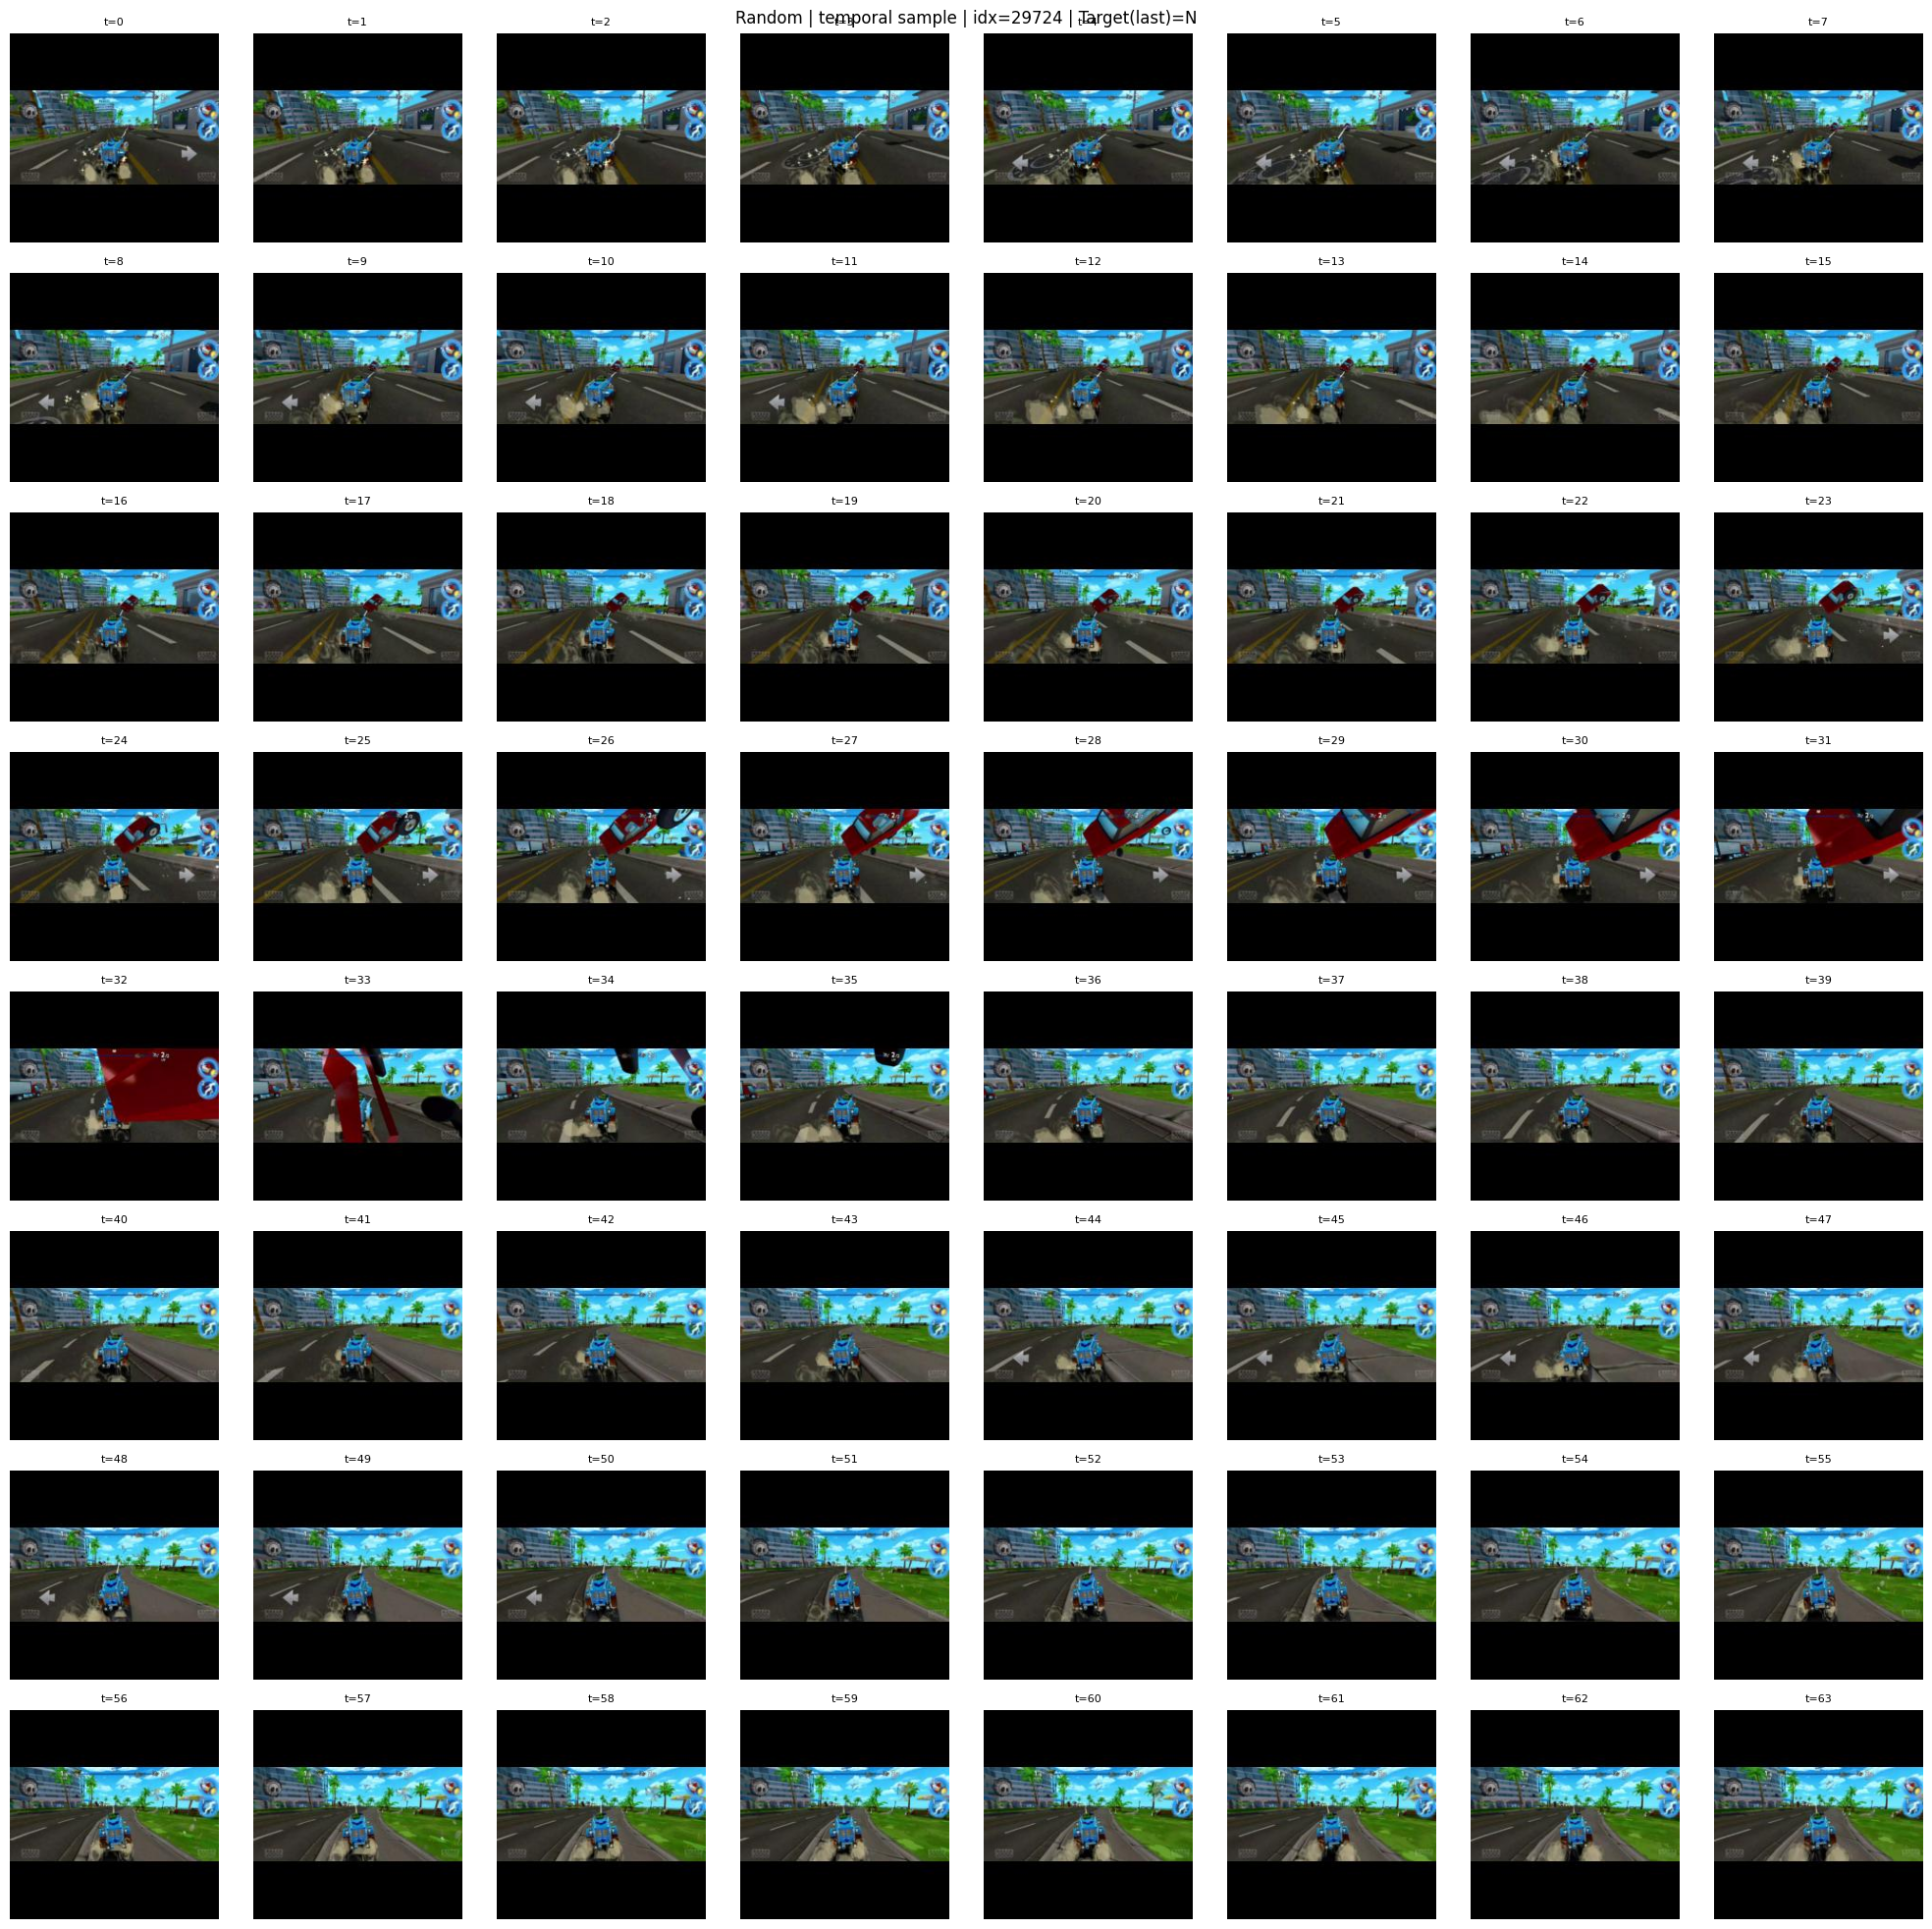

In [33]:
# Deterministic: first sample from Dataset (anchor index 0 in epoch_indices)
visualize_sequence_torch(train_ds1, random_sample=True, max_frames_to_show=64, dataset_index=6)


In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FrameCNN(nn.Module):
    """
    Per-frame CNN feature extractor that mirrors your Keras frame_cnn() block.

    Input:  (B, 3, H, W)
    Output: (B, 256)
    """
    def __init__(self, in_ch=3, dropout=0.2):
        super().__init__()

        # Block 1
        self.conv1a = nn.Conv2d(in_ch, 32, kernel_size=3, padding=1)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 3
        self.conv3a = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3a = nn.BatchNorm2d(128)
        self.conv3b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3b = nn.BatchNorm2d(128)

        # GAP
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # FC head (512 -> 256)
        self.fc1 = nn.Linear(128, 512)
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(512, 256)

    def forward(self, x):
        # x: (B,3,H,W)
        x = self.conv1a(x)
        x = F.relu(x)
        x = self.conv1b(x)
        #x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2a(x)
        x = F.relu(x)
        x = self.conv2b(x)
        #x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = self.conv3a(x)
        #x = self.bn3a(x)
        x = F.relu(x)
        x = self.conv3b(x)
        #x = self.bn3b(x)
        x = F.relu(x)

        x = self.gap(x)              # (B,128,1,1)
        x = x.flatten(1)             # (B,128)
        x = F.relu(self.fc1(x))      # (B,512)
        x = self.drop(x)
        x = F.relu(self.fc2(x))      # (B,256)
        return x


class CNNLSTM3Class(nn.Module):
    """
    Mirrors your Keras model:

      Input:  (B, T, 3, H, W)
      Frame CNN -> (B,T,256)
      LSTM -> (B,lstm_units) using last output
      Dense 128 + Dropout
      Classifier -> logits (B,n_classes)

    Use CrossEntropyLoss (expects logits).
    """
    def __init__(
        self,
        seq_len=128,
        image_size=(224, 224),
        n_classes=3,
        lstm_units=256,
        dropout=0.2,
        bidirectional=False,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.image_size = image_size
        self.n_classes = n_classes
        self.lstm_units = lstm_units
        self.bidirectional = bidirectional

        self.frame_cnn = FrameCNN(in_ch=3, dropout=dropout)

        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=lstm_units,
            num_layers=1,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.0,  # PyTorch LSTM dropout works only when num_layers > 1
        )

        lstm_out_dim = lstm_units * (2 if bidirectional else 1)

        self.fc_mid = nn.Linear(lstm_out_dim, 128)
        self.drop = nn.Dropout(dropout)
        self.fc_out = nn.Linear(128, n_classes)

    def forward(self, x):
        # x: (B,T,3,H,W)
        B, T, C, H, W = x.shape

        # Flatten time into batch for CNN: (B*T,3,H,W)
        x = x.reshape(B * T, C, H, W)
        feats = self.frame_cnn(x)          # (B*T,256)

        # Restore time: (B,T,256)
        feats = feats.reshape(B, T, 256)

        # LSTM over time
        out, (h_n, c_n) = self.lstm(feats)

        # Last time-step output (equivalent to return_sequences=False)
        last = out[:, -1, :]               # (B, lstm_out_dim)

        x = F.relu(self.fc_mid(last))      # (B,128)
        x = self.drop(x)
        logits = self.fc_out(x)            # (B,n_classes)
        return logits


# ---- Build model (equivalent to your build_cnn_lstm_for_frames) ----
seq_len = seq_len  # keep your existing variable
model = CNNLSTM3Class(
    seq_len=seq_len,
    image_size=(224, 224),
    n_classes=3,
    lstm_units=256,
    dropout=0.2,
    bidirectional=False,
)
print(model)


CNNLSTM3Class(
  (frame_cnn): FrameCNN(
    (conv1a): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv1b): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2a): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3a): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn3a): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3b): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn3b): BatchNorm2d(128

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CNN3D3Class(nn.Module):
    """
    3D CNN for video/frame sequences.

    Input:  X (B, T, 3, H, W) in [0,1]
    Output: logits (B, n_classes)

    Uses Conv3D over (T,H,W). Internally converts to (B,3,T,H,W).
    """
    def __init__(
        self,
        n_classes=3,
        dropout=0.2,
        base_channels=32,
        temporal_pool=True,
    ):
        super().__init__()

        c1 = base_channels
        c2 = base_channels * 2
        c3 = base_channels * 4

        # Block 1
        self.conv1a = nn.Conv3d(3, c1, kernel_size=3, padding=1)
        self.conv1b = nn.Conv3d(c1, c1, kernel_size=3, padding=1)
        #self.bn1 = nn.BatchNorm3d(c1)
        self.pool1 = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))  # downsample spatial only

        # Block 2
        self.conv2a = nn.Conv3d(c1, c2, kernel_size=3, padding=1)
        self.conv2b = nn.Conv3d(c2, c2, kernel_size=3, padding=1)
        #self.bn2 = nn.BatchNorm3d(c2)
        self.pool2 = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))  # spatial only

        # Block 3
        self.conv3a = nn.Conv3d(c2, c3, kernel_size=3, padding=1)
        self.conv3b = nn.Conv3d(c3, c3, kernel_size=3, padding=1)
        #self.bn3 = nn.BatchNorm3d(c3)

        # Optional temporal pooling: only makes sense if T > 1
        self.temporal_pool = temporal_pool
        if temporal_pool:
            self.pool_t = nn.MaxPool3d(kernel_size=(2, 1, 1), stride=(2, 1, 1))  # downsample time only

        # Global average pool over (T,H,W)
        self.gap = nn.AdaptiveAvgPool3d((1, 1, 1))

        self.drop = nn.Dropout(dropout)
        self.fc1 = nn.Linear(c3, 128)
        self.fc_out = nn.Linear(128, n_classes)

    def forward(self, x):
        # x: (B,T,3,H,W) -> (B,3,T,H,W)
        x = x.permute(0, 2, 1, 3, 4).contiguous()

        x = self.conv1a(x)
        x = self.conv1b(x)
        #x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2a(x)
        x = self.conv2b(x)
        #x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = self.conv3a(x)
        x = self.conv3b(x)
        #x = self.bn3(x)
        x = F.relu(x)

        # If you use seq_len=1, keep temporal_pool=False
        if self.temporal_pool and x.shape[2] >= 2:
            x = self.pool_t(x)

        x = self.gap(x).flatten(1)   # (B, c3)
        x = self.drop(F.relu(self.fc1(x)))
        logits = self.fc_out(x)
        return logits


# --- Build + loss/optimizer ---
model = CNN3D3Class(
    n_classes=3,
    dropout=0.2,
    base_channels=32,
    temporal_pool=True,  # set False if seq_len == 1
)


In [29]:

# ---- Loss + optimizer (equivalent compile) ----
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)  # ~L2
criterion = nn.CrossEntropyLoss()  # sparse labels (0/1/2), logits input

In [30]:
import time
import sys


def keras_progress_bar(
    step,
    total_steps,
    loss,
    acc,
    elapsed,
    bar_width=30,
    prefix="",
    eta=None,
):
    frac = step / total_steps
    filled = int(bar_width * frac)
    bar = "=" * filled + ">" + "." * (bar_width - filled - 1)

    msg = (
        f"\r{prefix}"
        f"{step}/{total_steps} "
        f"[{bar}] "
        f"- {elapsed:.0f}s"
    )

    if eta is not None:
        msg += f" - ETA: {eta}"

    msg += f" - loss: {loss:.4g} - accuracy: {acc:.4f}"
    sys.stdout.write(msg)
    sys.stdout.flush()


In [31]:
import torch
import numpy as np
import time


def train_model(
    model,
    train_loaders,   # list of train loaders (e.g. [train_loader1, train_loader2])
    val_loader,
    optimizer,
    criterion,
    epochs=10,
    device="cuda" if torch.cuda.is_available() else "cpu",
):
    model.to(device)

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")

        # -------------------------
        # TRAIN
        # -------------------------
        model.train()

        for ds in train_loaders:
            if hasattr(ds.dataset, "on_epoch_start"):
                ds.dataset.on_epoch_start()

        total_steps = sum(len(dl) for dl in train_loaders)
        step = 0

        running_loss = 0.0
        running_correct = 0
        running_total = 0

        start_time = time.time()

        for loader in train_loaders:
            for X, y in loader:
                step += 1

                X = X.to(device)          # (B,T,3,H,W)
                y = y.to(device)          # (B,)

                optimizer.zero_grad()
                logits = model(X)
                loss = criterion(logits, y)
                loss.backward()
                optimizer.step()

                # stats
                running_loss += loss.item() * y.size(0)
                preds = logits.argmax(dim=1)
                running_correct += (preds == y).sum().item()
                running_total += y.size(0)

                elapsed = time.time() - start_time
                acc = running_correct / max(1, running_total)

                # ETA
                steps_left = total_steps - step
                if step > 1:
                    sec_per_step = elapsed / step
                    eta = time.strftime("%M:%S", time.gmtime(steps_left * sec_per_step))
                else:
                    eta = None

                keras_progress_bar(
                    step=step,
                    total_steps=total_steps,
                    loss=running_loss / max(1, running_total),
                    acc=acc,
                    elapsed=elapsed,
                    eta=eta,
                )

        print()  # newline after epoch progress

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        # -------------------------
        # VALIDATION
        # -------------------------
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X, y in val_loader:
                X = X.to(device)
                y = y.to(device)

                logits = model(X)
                loss = criterion(logits, y)

                val_loss += loss.item() * y.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        epoch_time = time.time() - start_time

        # -------------------------
        # Epoch summary (Keras style)
        # -------------------------
        print(
            f"{total_steps}/{total_steps} "
            f"[==============================] "
            f"- {epoch_time:.0f}s "
            f"- loss: {train_loss:.4g} "
            f"- accuracy: {train_acc:.4f} "
            f"- val_loss: {val_loss:.4g} "
            f"- val_accuracy: {val_acc:.4f}"
        )


In [ ]:
train_model(
    model=model,
    train_loaders=[train_loader1],
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=100,
)



Epoch 1/100
67654/67654 [==============================] - 26260s - loss: 1.073 - accuracy: 0.4141 - val_loss: 1.066 - val_accuracy: 0.4599

Epoch 2/100
65006/67654 [============================>.] - 20683s - ETA: 14:02 - loss: 1.07 - accuracy: 0.41099

KeyboardInterrupt: 

In [43]:
#save the model
torch.save(model.state_dict(), "data\cnn_lstm_model.pth")

In [9]:
import random
import torch
import matplotlib.pyplot as plt

def predict_random_sequence(model, val_ds, device="cpu"):
    """
    Randomly pick one temporal window from val_ds and show GT vs prediction.
    Displays the *last frame* in the sequence window (the current frame).
    """

    model.eval()
    model.to(device)

    # Pick random sample
    idx = random.randint(0, len(val_ds) - 1)

    sample = val_ds[idx]
    # Your __getitem__ currently returns (X, y, ...) but you typed two variants above.
    # So handle both safely:
    if len(sample) == 2:
        X, y = sample
        extra = None
    else:
        X, y, extra = sample

    # X: (T,3,H,W) -> (1,T,3,H,W)
    Xb = X.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(Xb)                 # (1, n_classes)
        pred_idx = logits.argmax(dim=1).item()

    gt_idx = int(y.item())

    # Labels
    class_names = getattr(val_ds, "class_names", ["Left", "None", "Right"])
    gt_label = class_names[gt_idx]
    pred_label = class_names[pred_idx]

    # Show last frame in the window
    last_frame = X[-1].permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(5, 5))
    plt.imshow(last_frame)
    plt.axis("off")

    title = f"GT: {gt_label} | Pred: {pred_label}"
    if extra is not None:
        title = f"{extra}\n" + title  # extra could be filename or index info

    plt.title(title, fontsize=10)
    plt.show()

    # Print out clearly
    print(f"Dataset index : {idx}")
    if extra is not None:
        print(f"Extra        : {extra}")
    print(f"Ground Truth : {gt_label} ({gt_idx})")
    print(f"Prediction   : {pred_label} ({pred_idx})")


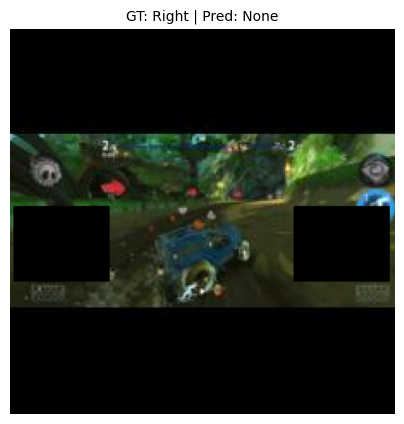

Dataset index : 27417
Ground Truth : Right (2)
Prediction   : None (1)


In [19]:
predict_random_sequence(model, val_ds, device="cuda")